<a href="https://colab.research.google.com/github/ignaciovgl/Multi-Asset-Trend-Following-Project/blob/main/Multi_asset_trend_following_backtest_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Data Infrastructure & Universe Selection — Goals

**Goals:**

- Build a multi-asset universe across 4 asset classes: equity indices, government bonds, FX majors, commodities
- Source data from free providers (yfinance), using a hybrid approach per instrument: real futures prices where available for free (US10Y, Gold, Crude, Copper), ETF proxies where futures data isn't freely available (Bund, Gilt)
- Maintain an INSTRUMENT_META table tagging each instrument's ticker, data source type, and asset class, to support source-aware decisions later (transaction costs, caveats in reporting)
- Pull maximum available history per instrument (targeting 2000–present), rather than truncating to the shortest series — preserving major macro regimes (2008 GFC, 2020 COVID) for instruments that have them
- Log actual data coverage per instrument (coverage_log.csv) and treat staggered start dates as expected, not an error — instruments enter the backtest on their own native start date
- Clean the data: forward-fill short genuine gaps (cross-exchange holiday mismatches), leave pre-inception NaNs untouched
- Convert prices to log returns as the common unit of measurement across all instruments
- Compute 21-day realised volatility (annualised) per instrument — foundation for volatility targeting in Phase 3
- Compute 63-day rolling correlations across instruments — foundation for portfolio-level risk accounting in Phase 3
- Milestone: clean, saved log_returns, realised_vol_21d, and rolling_corr_63d panels, ready to build signals on top of

## Update on phase 1
We started Week 1 by mapping the planned universe (equity indices, bonds, FX, commodities) onto actual free data sources, and hit a real constraint: yfinance doesn't provide back-adjusted futures for most instruments, and true continuous futures data (properly roll-adjusted) sits behind paid vendors. Rather than forcing a fake solution, we chose a per-instrument hybrid: real futures prices where yfinance actually offers them for free (ZN=F for US 10Y, GC=F/CL=F/HG=F for commodities), and liquid ETF proxies where no free futures exist (IS0L.DE for Bund, IGLT.L for Gilt). We accepted known, documentable tradeoffs on each side — unadjusted roll gaps in the futures series, expense-ratio drag and shorter history in the ETFs — rather than pretending the data is cleaner than it is. Because everything gets converted to daily log returns before any modeling happens, the pipeline itself is source-agnostic; the only thing we need to carry forward is a small metadata table tagging each instrument's source and asset class, so we can apply the right transaction-cost assumption later and flag caveats accurately in the final report.

In [1]:
!pip install yfinance pandas-market-calendars pyarrow -q

from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/trend_following_project'
os.makedirs(f'{PROJECT_DIR}/data/raw', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data/processed', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
INSTRUMENT_META = {
    'SPX':    {'ticker': '^GSPC',    'source': 'index',    'asset_class': 'equity'},
    'FTSE':   {'ticker': '^FTSE',    'source': 'index',    'asset_class': 'equity'},
    'DAX':    {'ticker': '^GDAXI',   'source': 'index',    'asset_class': 'equity'},
    'NIKKEI': {'ticker': '^N225',    'source': 'index',    'asset_class': 'equity'},

    'US10Y':  {'ticker': 'ZN=F',     'source': 'futures',  'asset_class': 'bond'},
    'BUND':   {'ticker': 'IS0L.DE',  'source': 'etf',      'asset_class': 'bond'},
    'GILT':   {'ticker': 'IGLT.L',   'source': 'etf',      'asset_class': 'bond'},

    'EURUSD': {'ticker': 'EURUSD=X', 'source': 'spot_fx',  'asset_class': 'fx'},
    'GBPUSD': {'ticker': 'GBPUSD=X', 'source': 'spot_fx',  'asset_class': 'fx'},
    'USDJPY': {'ticker': 'USDJPY=X', 'source': 'spot_fx',  'asset_class': 'fx'},
    'AUDUSD': {'ticker': 'AUDUSD=X', 'source': 'spot_fx',  'asset_class': 'fx'},

    'GOLD':   {'ticker': 'GC=F',     'source': 'futures',  'asset_class': 'commodity'},
    'CRUDE':  {'ticker': 'CL=F',     'source': 'futures',  'asset_class': 'commodity'},
    'COPPER': {'ticker': 'HG=F',     'source': 'futures',  'asset_class': 'commodity'},
}

import pandas as pd
meta_df = pd.DataFrame(INSTRUMENT_META).T
meta_df.to_csv(f'{PROJECT_DIR}/data/raw/instrument_meta.csv')
meta_df

,ticker,source,asset_class
SPX,^GSPC,index,equity
FTSE,^FTSE,index,equity
DAX,^GDAXI,index,equity
NIKKEI,^N225,index,equity
US10Y,ZN=F,futures,bond
BUND,IS0L.DE,etf,bond
GILT,IGLT.L,etf,bond
EURUSD,EURUSD=X,spot_fx,fx
GBPUSD,GBPUSD=X,spot_fx,fx
USDJPY,USDJPY=X,spot_fx,fx


In [3]:
import yfinance as yf

raw_data = {}
coverage_log = []

for name, meta in INSTRUMENT_META.items():
    ticker = meta['ticker']
    df = yf.download(ticker, start='2000-01-01', progress=False)
    if df.empty:
        print(f'WARNING: no data returned for {name} ({ticker})')
        coverage_log.append({'instrument': name, 'ticker': ticker, 'start': None, 'end': None, 'rows': 0})
        continue

    raw_data[name] = df['Close']
    coverage_log.append({
        'instrument': name, 'ticker': ticker,
        'start': df.index.min().date(), 'end': df.index.max().date(), 'rows': len(df)
    })
    df.to_csv(f'{PROJECT_DIR}/data/raw/{name}.csv')

coverage_df = pd.DataFrame(coverage_log)
coverage_df.to_csv(f'{PROJECT_DIR}/data/raw/coverage_log.csv', index=False)
coverage_df

/tmp/ipykernel_7417/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_7417/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_7417/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_7417/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_7417/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_7417/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to 

,instrument,ticker,start,end,rows
0,SPX,^GSPC,2000-01-03,2026-09-22,6720
1,FTSE,^FTSE,2000-01-04,2026-09-23,6750
2,DAX,^GDAXI,2000-01-03,2026-09-23,6786
3,NIKKEI,^N225,2000-01-04,2026-09-18,6544
4,US10Y,ZN=F,2000-09-21,2026-09-23,6530
5,BUND,IS0L.DE,2012-05-08,2026-09-23,3645
6,GILT,IGLT.L,2008-01-02,2026-09-23,4730
7,EURUSD,EURUSD=X,2003-12-01,2026-09-23,5919
8,GBPUSD,GBPUSD=X,2003-12-01,2026-09-23,5931
9,USDJPY,USDJPY=X,2000-01-03,2026-09-23,6939


In [4]:
prices = pd.concat(raw_data, axis=1).sort_index()

if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.get_level_values(0)  # keep 'SPX', 'FTSE', etc., drop the ticker level

print(prices.columns.tolist())

['SPX', 'FTSE', 'DAX', 'NIKKEI', 'US10Y', 'BUND', 'GILT', 'EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'GOLD', 'CRUDE', 'COPPER']


In [5]:
# Forward-fill short genuine gaps (holiday mismatches across exchanges),
# but leave pre-inception NaNs alone — don't fabricate history
prices_clean = prices.ffill(limit=5)

nan_report = prices_clean.isna().sum()
print('Remaining NaNs per instrument (should mostly reflect pre-inception gaps):')
print(nan_report)

Remaining NaNs per instrument (should mostly reflect pre-inception gaps):
SPX          0
FTSE         1
DAX          0
NIKKEI       2
US10Y      190
BUND      3221
GILT      2087
EURUSD    1026
GBPUSD    1020
USDJPY       6
AUDUSD    1661
GOLD       172
CRUDE      167
COPPER     172
dtype: int64


In [6]:
import numpy as np

log_returns = np.log(prices_clean / prices_clean.shift(1))
realised_vol_21d = log_returns.rolling(21).std() * np.sqrt(252)
rolling_corr_63d = log_returns.rolling(63).corr()

log_returns.to_parquet(f'{PROJECT_DIR}/data/processed/log_returns.parquet')
realised_vol_21d.to_parquet(f'{PROJECT_DIR}/data/processed/realised_vol_21d.parquet')
rolling_corr_63d.to_parquet(f'{PROJECT_DIR}/data/processed/rolling_corr_63d.parquet')

print('Saved: log_returns, realised_vol_21d, rolling_corr_63d')

/usr/local/lib/python3.13/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Saved: log_returns, realised_vol_21d, rolling_corr_63d


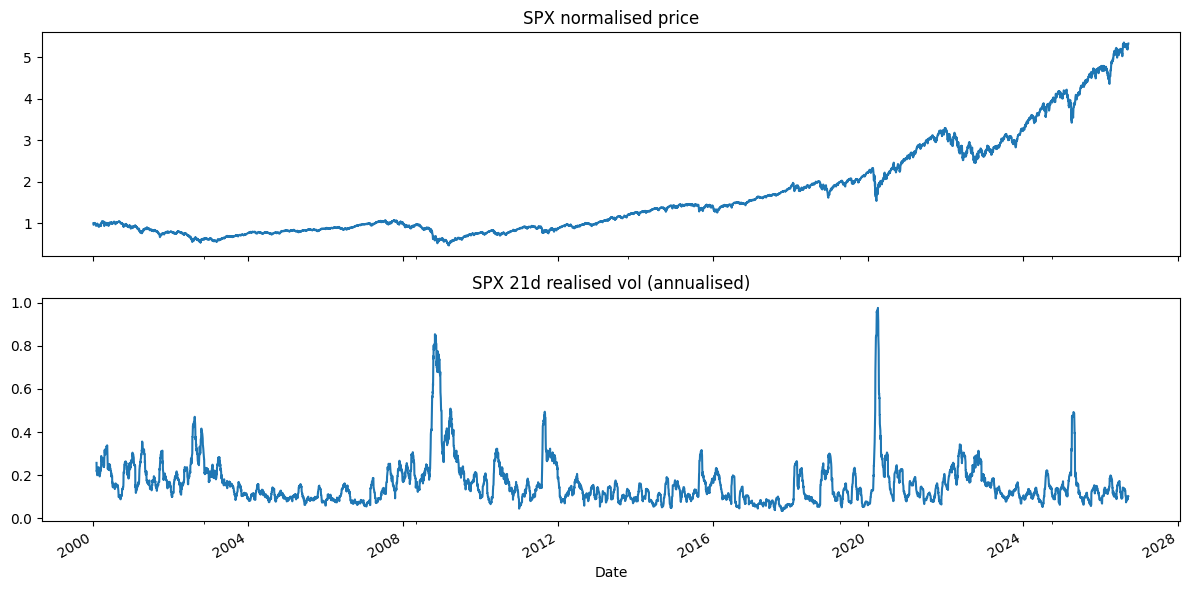

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
(prices_clean['SPX'] / prices_clean['SPX'].dropna().iloc[0]).plot(ax=axes[0], title='SPX normalised price')
realised_vol_21d['SPX'].plot(ax=axes[1], title='SPX 21d realised vol (annualised)')
plt.tight_layout()
plt.show()

## Explanation phase 1
All price series are converted to log returns rather than simple returns, since log returns are time-additive (returns over multiple periods simply sum, unlike simple returns which compound multiplicatively) and behave more symmetrically across instruments with very different price levels and volatility profiles. This makes them the standard choice whenever computing statistics on returns, as we do throughout this project.


From log returns we compute two key metrics that don't feed into the trading signals directly, but are essential inputs for portfolio construction in Week 3. Realised volatility (21-day rolling standard deviation of returns, annualised) measures how much each instrument is currently moving, and is the basis for volatility targeting — sizing each position so it contributes a comparable amount of risk to the portfolio, since a 1% daily move means something very different for EURUSD than for Gold.

Rolling correlation (63-day window) measures how instruments move together, which matters because portfolio-level risk depends not just on individual position sizes but on how those positions interact — diversification benefit shrinks (and can disappear entirely) when correlations rise, which they notably do during market stress (2008, 2020).

Tracking this on a rolling rather than static basis lets the portfolio construction step account for changing regimes rather than assuming a fixed average relationship that breaks down exactly when it matters most.

Note also that instruments enter the dataset on their own native start dates (see coverage_log.csv) rather than being truncated to a common window — this preserves 12+ years of history (including the 2008 GFC) for instruments like equities, US10Y futures, and commodities that would otherwise be discarded to accommodate later-starting series like the Bund ETF proxy (2012).

Downstream signal and portfolio logic is written to operate on whatever instruments have valid data on a given date, rather than assuming a fixed, static universe throughout the backtest.

# Phase 2: Signal Construction — Goals

- Implement at least 3 trend-following signals:

   - EWMA crossover (fast/slow window pairs)
   - Time series momentum (12-1 month return)
   - Donchian channel breakout
- Normalise each signal to a [-1, +1] range to make them directly comparable and combinable
- Combine signals into a composite score:
    - Start with equal weighting across signals
    - Then test a risk-weighted combination
- Visually validate signals against price for 4–5 instruments — confirm signals behave intuitively at known trend/reversal points
- Handle the staggered universe correctly: signals should only be computed/considered valid for instruments with sufficient live history at each point in time
- Milestone: a clean signal matrix (instruments × dates) saved as a DataFrame, ready for position sizing in Phase 3

## Development of trend-following signals
Three complementary trend-following signals are constructed, each capturing a different aspect of trend behaviour.

EWMA crossover compares fast and slow exponentially-weighted moving averages across multiple time horizons, capturing whether recent price action is outpacing the longer-term trend.

Time series momentum (12-1 month) measures the return over the past year, excluding the most recent month to avoid short-term mean-reversion effects well documented in the momentum literature, capturing longer-horizon persistence.

Donchian channel breakout measures where price sits relative to its recent high-low range, capturing genuine breakouts from consolidation rather than smoothed trend strength.

Each raw signal is normalised using its own rolling historical spread and squashed with tanh to a common [-1, +1] scale, making the three directly comparable despite being computed on entirely different bases (percentage-of-price, period return, and range position respectively).

This diversity is intentional: combining signals with different mechanisms and horizons produces a more robust composite than relying on any single trend measure, and is standard practice in systematic trend-following strategies.

### EWMA Crossover

In [8]:
def ewma_crossover_signal(prices, pairs=[(8, 32), (16, 64), (32, 128)]):
    """
    prices: DataFrame (dates x instruments)
    pairs: list of (fast_span, slow_span) tuples
    Returns: DataFrame of raw (unnormalised) crossover signal, averaged across pairs
    """
    signals = []
    for fast_span, slow_span in pairs:
        fast_ema = prices.ewm(span=fast_span, min_periods=fast_span).mean()
        slow_ema = prices.ewm(span=slow_span, min_periods=slow_span).mean()
        # Scale by price so the raw signal is comparable across instruments
        # regardless of absolute price level (e.g. Nikkei ~30000 vs EURUSD ~1.1)
        raw_signal = (fast_ema - slow_ema) / prices
        signals.append(raw_signal)

    combined = sum(signals) / len(signals)
    return combined

ewma_raw = ewma_crossover_signal(prices_clean)

### Time Series Momentum (12-1 month)

In [9]:
def tsmom_signal(prices, lookback_months=12, skip_months=1):
    """
    12-1 month momentum: return from t-252 to t-21, skipping the most recent month
    Approximating months as 21 trading days each
    """
    lookback_days = lookback_months * 21
    skip_days = skip_months * 21

    price_then = prices.shift(lookback_days)
    price_recent = prices.shift(skip_days)

    raw_signal = (price_recent / price_then) - 1
    return raw_signal

tsmom_raw = tsmom_signal(prices_clean)

### Donchian Channel

In [10]:
def donchian_signal(prices, window=50):
    """
    Donchian channel: signal = where price sits within the recent high-low range,
    scaled to roughly [-1, 1] before it goes into the general normalisation step
    """
    rolling_high = prices.rolling(window, min_periods=window).max()
    rolling_low = prices.rolling(window, min_periods=window).min()
    mid = (rolling_high + rolling_low) / 2
    half_range = (rolling_high - rolling_low) / 2

    raw_signal = (prices - mid) / half_range  # already roughly bounded, but not exactly
    return raw_signal

donchian_raw = donchian_signal(prices_clean)

### Normalised Signals

In [11]:
import numpy as np

def normalise_signal(raw_signal, scale_window=252):
    """
    Normalise using rolling standard deviation of the signal itself,
    then squash to [-1, 1] with tanh so extreme values don't dominate
    """
    rolling_std = raw_signal.rolling(scale_window, min_periods=scale_window//2).std()
    z = raw_signal / rolling_std
    normalised = np.tanh(z)
    return normalised

ewma_norm = normalise_signal(ewma_raw)
tsmom_norm = normalise_signal(tsmom_raw)
donchian_norm = normalise_signal(donchian_raw)

## Plots for signals

### EWMA Crossover Signal

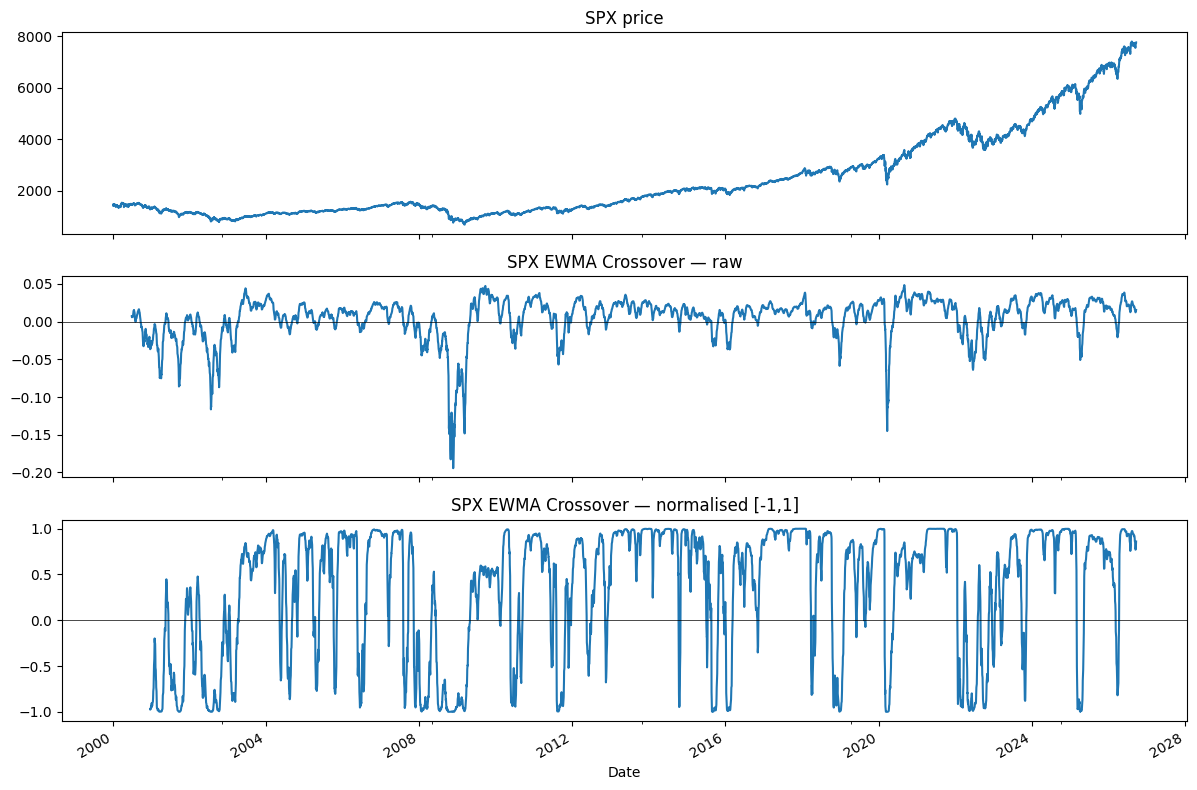

--- EWMA Crossover sanity stats for SPX ---
Raw signal: min=-0.1944, max=0.0483, mean=0.0052
Normalised signal: min=-1.0000, max=1.0000, % positive=71.8%
NaN count: 252 / 6971



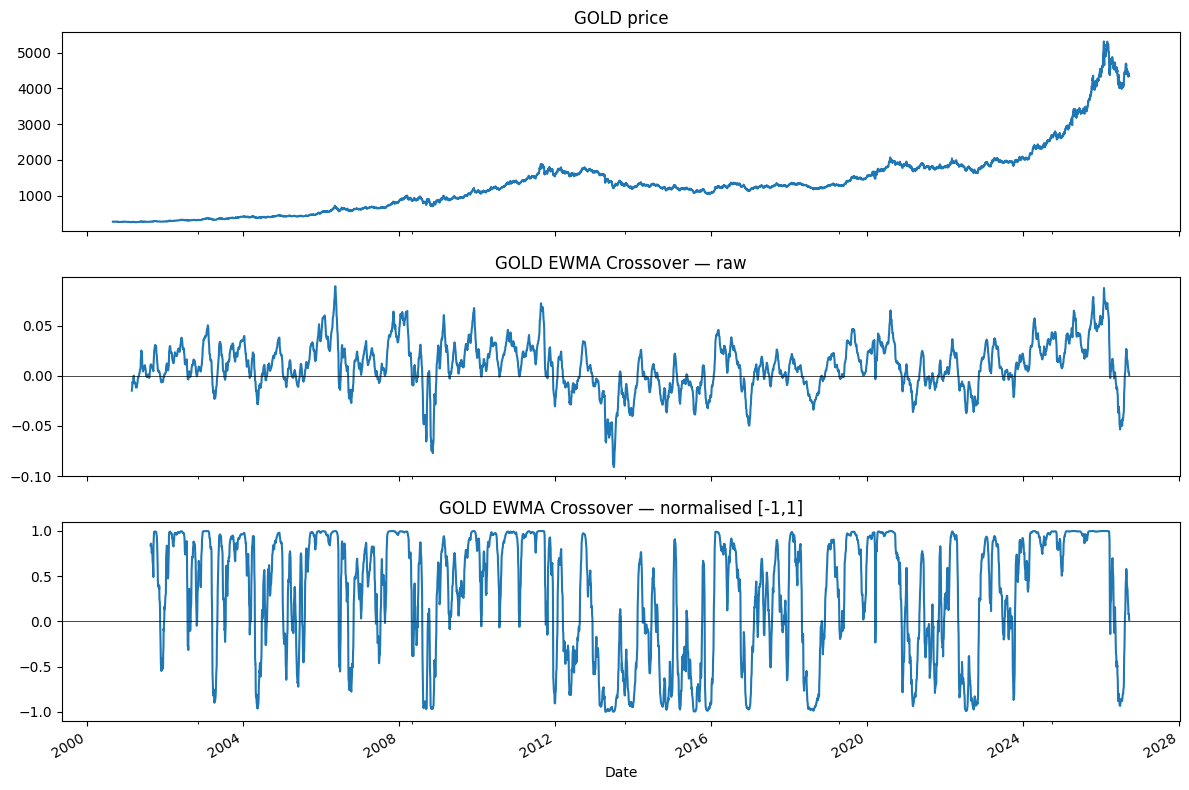

--- EWMA Crossover sanity stats for GOLD ---
Raw signal: min=-0.0910, max=0.0892, mean=0.0102
Normalised signal: min=-0.9984, max=1.0000, % positive=68.7%
NaN count: 424 / 6971



In [14]:
def check_signal(raw_signal, norm_signal, prices, instrument, signal_name, n_years=5):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    prices_series = prices[instrument]
    raw_signal_series = raw_signal[instrument]
    norm_signal_series = norm_signal[instrument]

    prices_series.plot(ax=axes[0], title=f'{instrument} price')

    raw_signal_series.plot(ax=axes[1], title=f'{instrument} {signal_name} — raw')
    axes[1].axhline(0, color='black', linewidth=0.5)

    norm_signal_series.plot(ax=axes[2], title=f'{instrument} {signal_name} — normalised [-1,1]')
    axes[2].axhline(0, color='black', linewidth=0.5)
    axes[2].set_ylim(-1.1, 1.1)

    plt.tight_layout()
    plt.show()

    print(f'--- {signal_name} sanity stats for {instrument} ---')
    print(f'Raw signal: min={raw_signal_series.min():.4f}, max={raw_signal_series.max():.4f}, '
          f'mean={raw_signal_series.mean():.4f}')
    print(f'Normalised signal: min={norm_signal_series.min():.4f}, max={norm_signal_series.max():.4f}, '
          f'% positive={100 * (norm_signal_series.dropna() > 0).mean():.1f}%')
    print(f'NaN count: {norm_signal_series.isna().sum()} / {len(norm_signal_series)}\n')

for inst in ['SPX', 'GOLD']:
    check_signal(ewma_raw, ewma_norm, prices_clean, inst, 'EWMA Crossover')

### Time Series Momentum Signal Plot

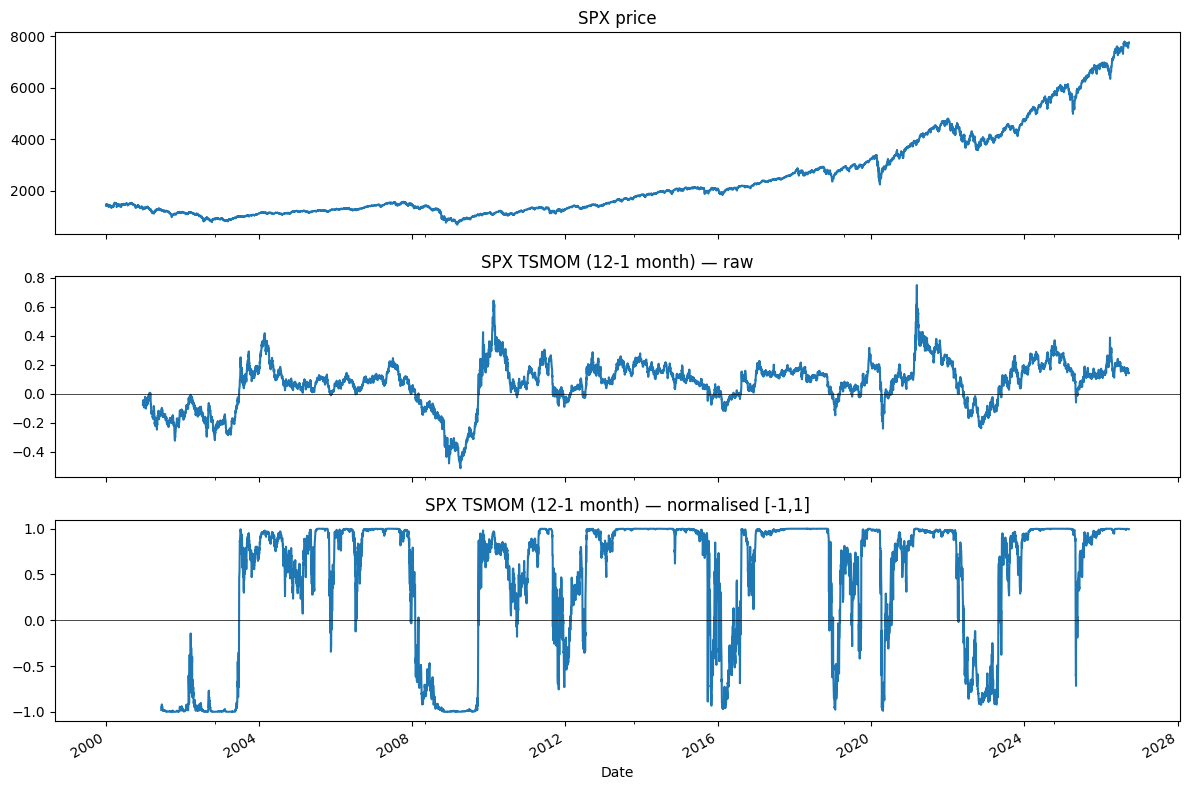

--- TSMOM (12-1 month) sanity stats for SPX ---
Raw signal: min=-0.5134, max=0.7481, mean=0.0688
Normalised signal: min=-0.9999, max=1.0000, % positive=75.6%
NaN count: 377 / 6971



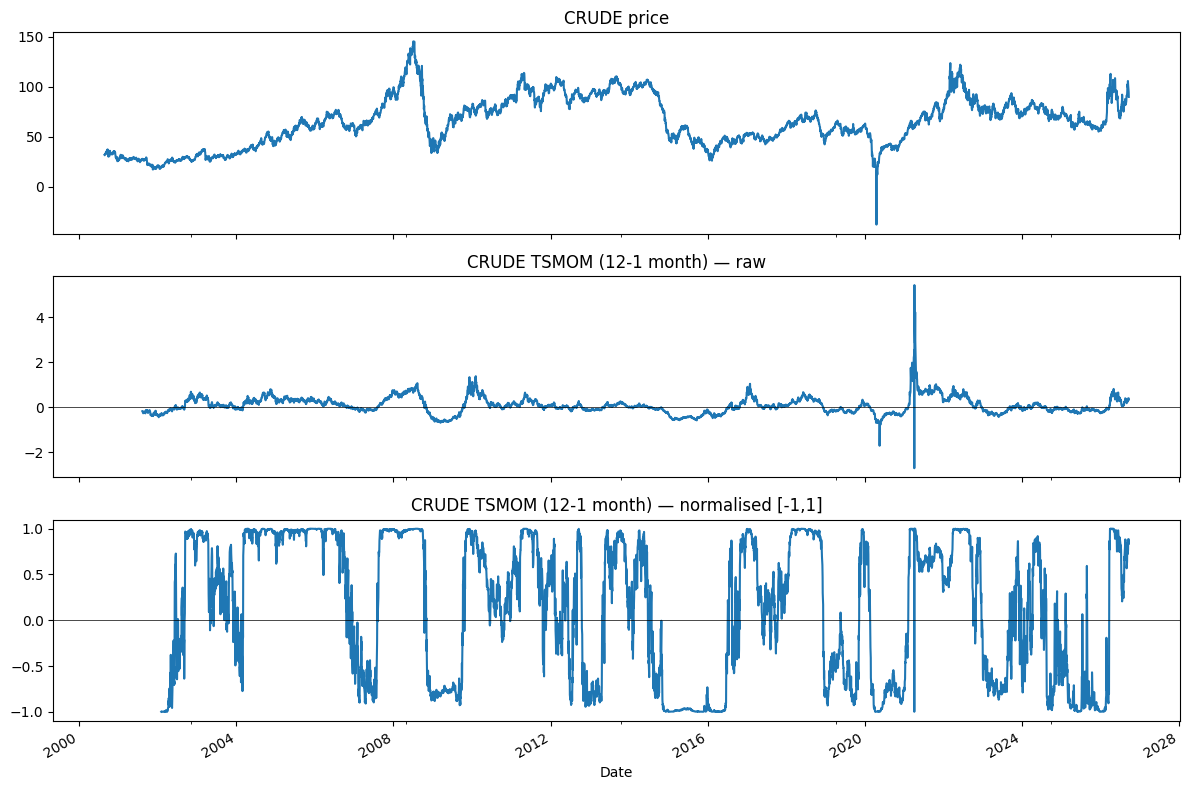

--- TSMOM (12-1 month) sanity stats for CRUDE ---
Raw signal: min=-2.7010, max=5.4376, mean=0.0910
Normalised signal: min=-1.0000, max=1.0000, % positive=58.3%
NaN count: 544 / 6971

TSMOM vs naive 12m momentum — mean abs difference: 0.0351
(should be small but non-zero — confirms the skip-month logic is doing something, not accidentally identical to naive momentum)


In [20]:
for inst in ['SPX', 'CRUDE']:
    check_signal(tsmom_raw, tsmom_norm, prices_clean, inst, 'TSMOM (12-1 month)')

# Extra check specific to TSMOM: verify it's genuinely skipping the last month
naive_12m = (prices_clean / prices_clean.shift(252)) - 1

spx_tsmom_raw = tsmom_raw['SPX']
spx_naive_12m = naive_12m['SPX']

diff = (spx_tsmom_raw - spx_naive_12m).dropna()
print(f'TSMOM vs naive 12m momentum — mean abs difference: {diff.abs().mean():.4f}')
print('(should be small but non-zero — confirms the skip-month logic is doing something, '
      'not accidentally identical to naive momentum)')

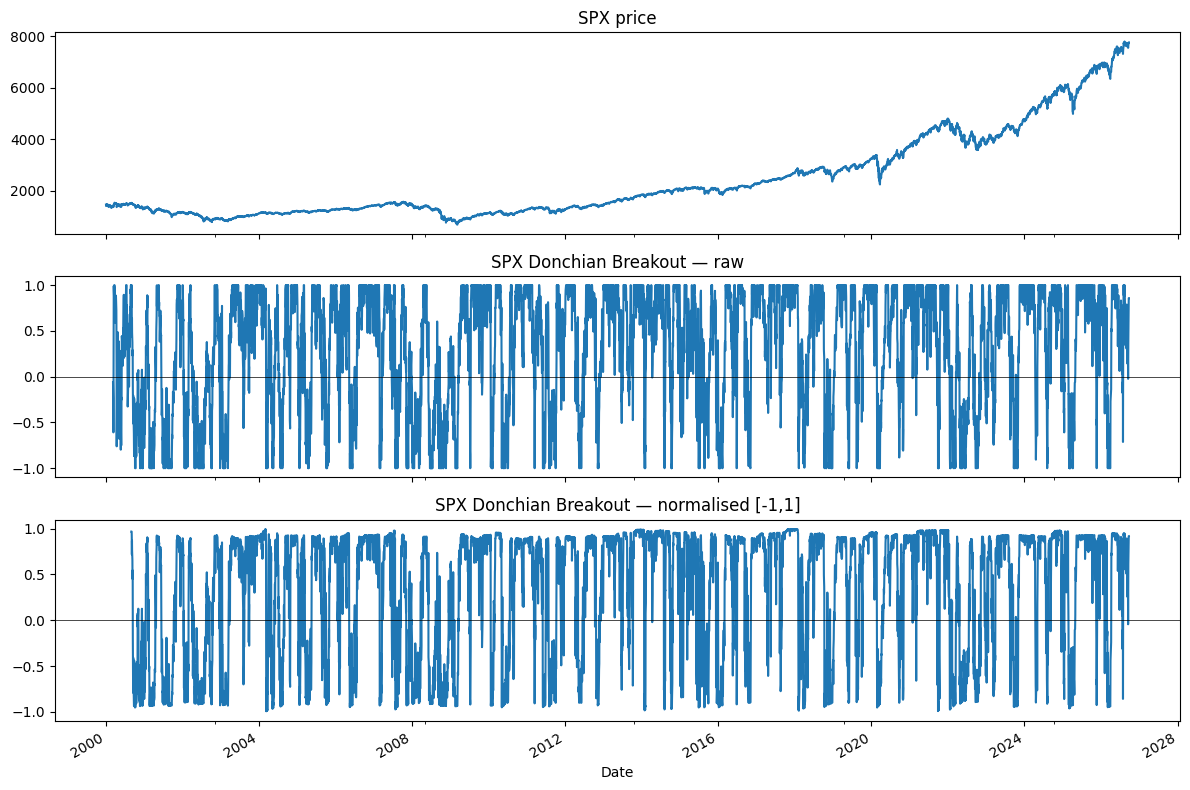

--- Donchian Breakout sanity stats for SPX ---
Raw signal: min=-1.0000, max=1.0000, mean=0.3280
Normalised signal: min=-0.9939, max=0.9945, % positive=69.3%
NaN count: 174 / 6971



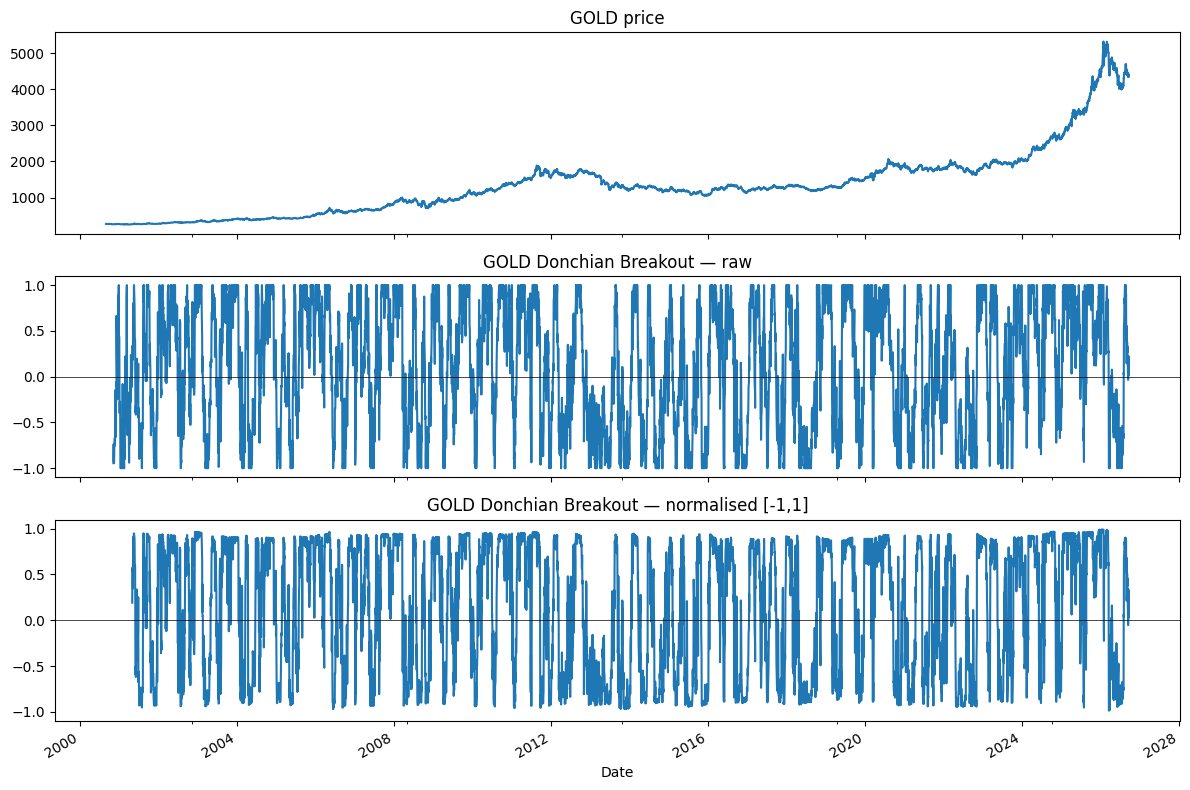

--- Donchian Breakout sanity stats for GOLD ---
Raw signal: min=-1.0000, max=1.0000, mean=0.1307
Normalised signal: min=-0.9872, max=0.9897, % positive=57.9%
NaN count: 346 / 6971

SPX all-time high on 2026-08-13: Donchian normalised = 0.947 (should be strongly positive, near +1)
SPX 2020 crash low on 2020-03-23: Donchian normalised = -0.913 (should be strongly negative, near -1)


In [22]:
for inst in ['SPX', 'GOLD']:
    check_signal(donchian_raw, donchian_norm, prices_clean, inst, 'Donchian Breakout')

# Extra check specific to Donchian: confirm sign convention is correct
spx_ath_date = prices_clean['SPX'].idxmax()
spx_crash_low_2020 = prices_clean['SPX']['2020-02-01':'2020-04-01'].idxmin()

print(f"SPX all-time high on {spx_ath_date.date()}: Donchian normalised = "
      f"{donchian_norm.loc[spx_ath_date, 'SPX']:.3f} (should be strongly positive, near +1)")
print(f"SPX 2020 crash low on {spx_crash_low_2020.date()}: Donchian normalised = "
      f"{donchian_norm.loc[spx_crash_low_2020, 'SPX']:.3f} (should be strongly negative, near -1)")

### Combined Signal

In [23]:
composite_signal = (ewma_norm + tsmom_norm + donchian_norm) / 3
composite_signal.to_parquet(f'{PROJECT_DIR}/data/processed/composite_signal_equal_weight.parquet')

print(isinstance(composite_signal.columns, pd.MultiIndex))  # should now print False
print(composite_signal.columns.tolist()[:3])

False
['SPX', 'FTSE', 'DAX']


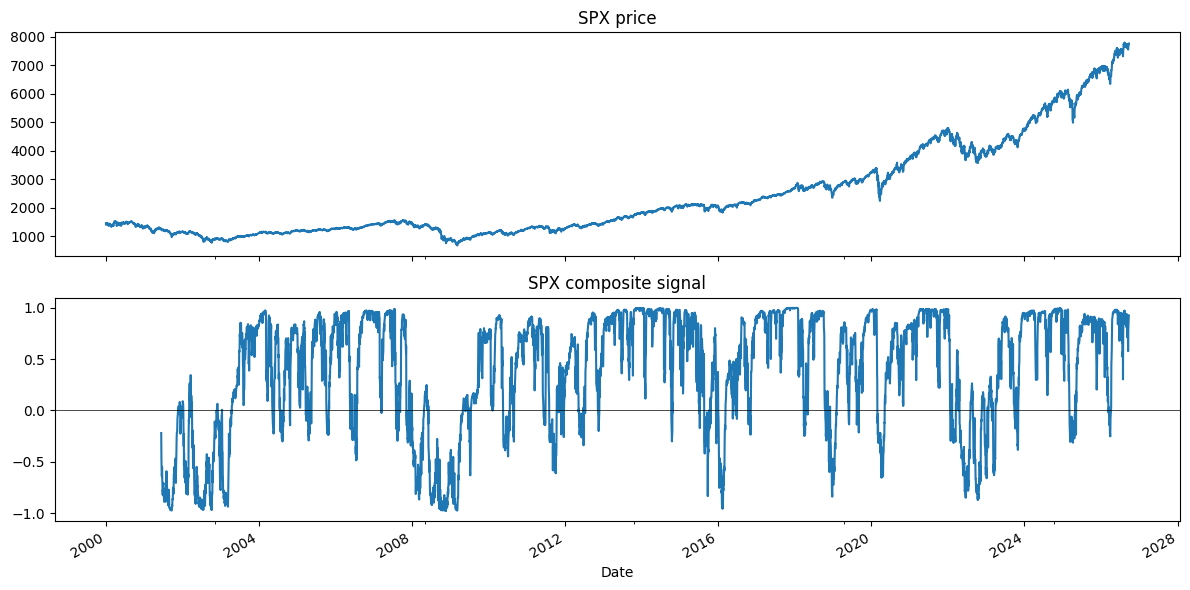

In [24]:
import matplotlib.pyplot as plt

instrument = 'SPX'
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
prices_clean[instrument].plot(ax=axes[0], title=f'{instrument} price')
composite_signal[instrument].plot(ax=axes[1], title=f'{instrument} composite signal')
axes[1].axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Phase 3: Position Sizing & Portfolio Construction

## Instrument-Level Volatility Targeting

In [25]:
DAILY_VOL_TARGET = 0.01  # 1% target daily vol contribution per instrument at full conviction

def instrument_level_positions(composite_signal, realised_vol_21d, vol_target=DAILY_VOL_TARGET):
    """
    Position size (in return-space units, i.e. fraction of notional) such that
    full-conviction signal (+/-1) times this position implies ~vol_target daily vol.
    """
    # Convert annualised realised vol back to daily for consistent units
    daily_vol = realised_vol_21d / np.sqrt(252)

    position = composite_signal * (vol_target / daily_vol)
    return position

raw_positions = instrument_level_positions(composite_signal, realised_vol_21d)

## Position Limits

In [26]:
POSITION_CAP = 0.2

capped_positions = raw_positions.clip(lower=-POSITION_CAP, upper=POSITION_CAP)

## Portfolio-level vol targeting (leverage scaling)

In [27]:
PORTFOLIO_VOL_TARGET = 0.10  # 10% annualised

def portfolio_level_scaling(capped_positions, log_returns, portfolio_vol_target=PORTFOLIO_VOL_TARGET, vol_lookback=63):
    """
    Computes trailing realised portfolio vol from the (pre-leverage) position * returns series,
    then derives a daily leverage multiplier to scale the whole portfolio to the target.
    """
    # Simulated pre-leverage daily portfolio return: sum of position * next-day return
    # (T+1 execution handled here already since we shift positions by 1 before applying returns)
    position_returns = capped_positions.shift(1) * log_returns

    portfolio_daily_return = position_returns.sum(axis=1, skipna=True)

    trailing_portfolio_vol = portfolio_daily_return.rolling(vol_lookback, min_periods=vol_lookback//2).std() * np.sqrt(252)

    leverage = portfolio_vol_target / trailing_portfolio_vol
    leverage = leverage.clip(upper=5)  # sanity cap on leverage itself, avoid extreme blow-ups in dead-quiet periods

    return leverage, portfolio_daily_return

leverage, _ = portfolio_level_scaling(capped_positions, log_returns)

final_positions = capped_positions.multiply(leverage, axis=0)

## Transaction Costs

In [28]:
TCOST_BPS = {
    'futures': 0.1,
    'spot_fx': 0.1,
    'index': 0.1,
    'etf': 0.5,
}

def apply_transaction_costs(final_positions, instrument_meta):
    """
    Cost = turnover (abs change in position) * cost rate (in decimal, bps/10000) per instrument
    """
    turnover = final_positions.diff().abs()

    cost_rates = pd.Series({
        inst: TCOST_BPS[meta['source']] / 10000
        for inst, meta in instrument_meta.items()
    })

    daily_costs = turnover.multiply(cost_rates, axis=1, level=0)
    return daily_costs

daily_costs = apply_transaction_costs(final_positions, INSTRUMENT_META)

## Portfolio Return

In [29]:
gross_position_returns = final_positions.shift(1) * log_returns
net_position_returns = gross_position_returns - daily_costs

net_portfolio_return = net_position_returns.sum(axis=1, skipna=True)

net_portfolio_return.to_frame('portfolio_return').to_parquet(
    f'{PROJECT_DIR}/data/processed/net_portfolio_returns_phase3.parquet'
)

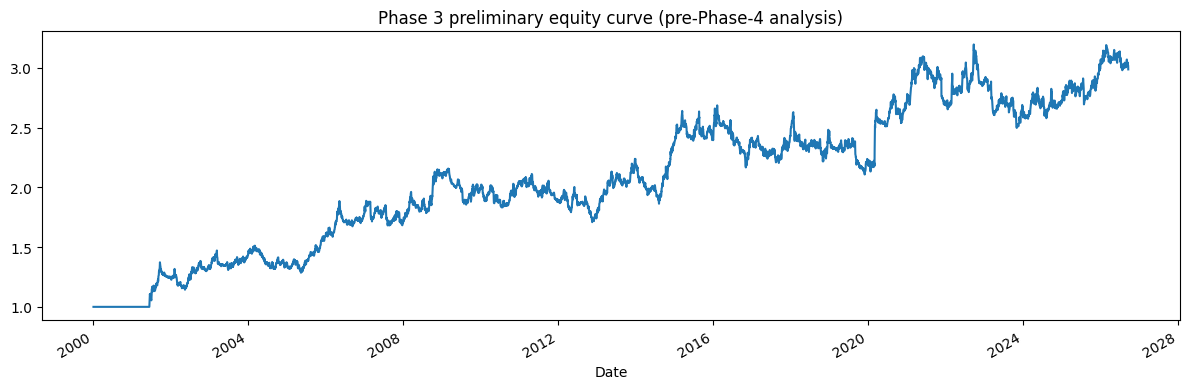

Annualised return: 4.52%
Annualised vol: 10.65% (target was 10%)
Rough Sharpe: 0.42


In [30]:
cumulative = (1 + net_portfolio_return.fillna(0)).cumprod()

fig, ax = plt.subplots(figsize=(12, 4))
cumulative.plot(ax=ax, title='Phase 3 preliminary equity curve (pre-Phase-4 analysis)')
plt.tight_layout()
plt.show()

print(f'Annualised return: {net_portfolio_return.mean() * 252:.2%}')
print(f'Annualised vol: {net_portfolio_return.std() * np.sqrt(252):.2%} (target was {PORTFOLIO_VOL_TARGET:.0%})')
print(f'Rough Sharpe: {(net_portfolio_return.mean() * 252) / (net_portfolio_return.std() * np.sqrt(252)):.2f}')

**Position sizing methodology:**

Signals are converted into positions through a two-stage volatility-targeting process, the industry-standard approach to multi-asset risk sizing.

First, each instrument's position is scaled by its own realised volatility so that a full-conviction signal contributes a fixed 1% daily volatility regardless of asset class — this makes signals across very different instruments (e.g. EURUSD vs Crude) risk-comparable rather than notionally comparable.

Positions are capped at 20% notional to prevent temporary low-volatility periods from producing outsized bets.


Second, portfolio-level leverage is scaled dynamically so total realised portfolio volatility (accounting for correlation between instruments) targets 10% annualised — this automatically de-risks the whole book during periods when correlations spike, such as market crises, which single-instrument sizing alone would miss. Transaction costs are applied per instrument based on turnover and a liquidity-dependent cost rate (lower for futures/FX, higher for ETF-sourced instruments), and all signals are executed with a one-day lag (T+1) to avoid look-ahead bias, reflecting realistic trading conditions.

# Phase 4: Backtesting & performance analysis


## In-sample vs out-of-sample split

In [31]:
IN_SAMPLE_END = '2015-01-01'

is_mask = net_portfolio_return.index < IN_SAMPLE_END
oos_mask = net_portfolio_return.index >= IN_SAMPLE_END

returns_is = net_portfolio_return[is_mask]
returns_oos = net_portfolio_return[oos_mask]

## Performance metrics

In [32]:
def compute_performance_metrics(log_returns_series, periods_per_year=252):
    """
    Computes standard performance metrics from a series of LOG returns.
    """
    returns = log_returns_series.dropna()

    # Equity curve — correct construction for log returns (see Phase 3 discussion)
    equity_curve = np.exp(returns.cumsum())

    # Annualised return: report the compounded-equivalent figure, not raw log mean
    ann_return = np.expm1(returns.mean() * periods_per_year)

    # Annualised vol: std of log returns scales additively under sqrt(time),
    # this remains the standard convention
    ann_vol = returns.std() * np.sqrt(periods_per_year)

    # Sharpe ratio (assuming 0% risk-free rate for simplicity — see note below)
    sharpe = (returns.mean() * periods_per_year) / (returns.std() * np.sqrt(periods_per_year))

    # Drawdown series: % below running peak of the equity curve
    running_max = equity_curve.cummax()
    drawdown = (equity_curve / running_max) - 1
    max_drawdown = drawdown.min()

    # Drawdown duration: longest number of consecutive days underwater
    underwater = drawdown < 0
    # Identify consecutive underwater streaks
    streak_id = (~underwater).cumsum()
    streak_lengths = underwater.groupby(streak_id).sum()
    max_dd_duration = streak_lengths.max()

    # Calmar ratio: annualised return / abs(max drawdown)
    calmar = ann_return / abs(max_drawdown) if max_drawdown != 0 else np.nan

    return {
        'annualised_return': ann_return,
        'annualised_vol': ann_vol,
        'sharpe': sharpe,
        'calmar': calmar,
        'max_drawdown': max_drawdown,
        'max_drawdown_duration_days': max_dd_duration,
        'equity_curve': equity_curve,
        'drawdown_series': drawdown,
    }

metrics_is = compute_performance_metrics(returns_is)
metrics_oos = compute_performance_metrics(returns_oos)
metrics_full = compute_performance_metrics(net_portfolio_return)

summary = pd.DataFrame({
    'In-Sample (2000-2015)': {k: v for k, v in metrics_is.items() if k not in ['equity_curve', 'drawdown_series']},
    'Out-of-Sample (2015-present)': {k: v for k, v in metrics_oos.items() if k not in ['equity_curve', 'drawdown_series']},
    'Full Period': {k: v for k, v in metrics_full.items() if k not in ['equity_curve', 'drawdown_series']},
}).T

summary

,annualised_return,annualised_vol,sharpe,calmar,max_drawdown,max_drawdown_duration_days
In-Sample (2000-2015),0.062602,0.104630,0.580334,0.326835,-0.191539,1098.0
Out-of-Sample (2015-present),0.025716,0.108792,0.233393,0.120149,-0.214037,1068.0
Full Period,0.046261,0.106474,0.424727,0.216133,-0.214037,1098.0


## Breakdown by Asset Class

In [33]:
def breakdown_by_asset_class(net_position_returns, instrument_meta):
    """
    net_position_returns: instrument-level daily net returns (pre-sum), from Phase 3
    """
    asset_class_map = {inst: meta['asset_class'] for inst, meta in instrument_meta.items()}

    by_class = net_position_returns.T.groupby(asset_class_map).sum().T

    class_metrics = {}
    for asset_class in by_class.columns:
        class_metrics[asset_class] = compute_performance_metrics(by_class[asset_class])

    class_summary = pd.DataFrame({
        k: {m: v for m, v in metrics.items() if m not in ['equity_curve', 'drawdown_series']}
        for k, metrics in class_metrics.items()
    }).T

    return class_summary, by_class

class_summary, returns_by_class = breakdown_by_asset_class(net_position_returns, INSTRUMENT_META)
class_summary

,annualised_return,annualised_vol,sharpe,calmar,max_drawdown,max_drawdown_duration_days
bond,-0.001034,0.016986,-0.060885,-0.010959,-0.094322,4364.0
commodity,0.018240,0.062971,0.287042,0.135752,-0.134361,1235.0
equity,0.021456,0.064383,0.329732,0.086346,-0.248490,3319.0
fx,0.006976,0.030580,0.227344,0.087834,-0.079427,1387.0


## Plots

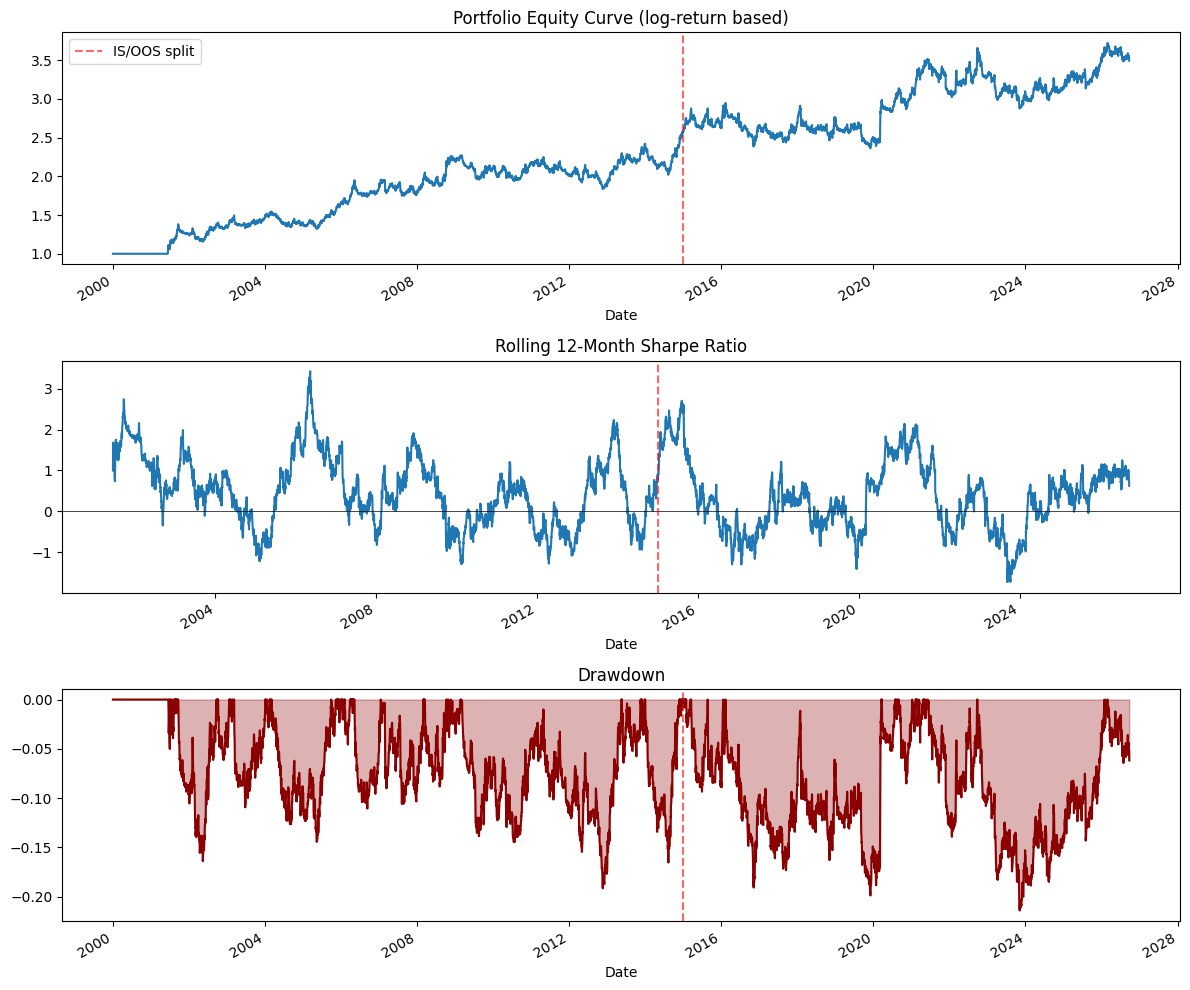

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# Equity curve, with in-sample/out-of-sample boundary marked
metrics_full['equity_curve'].plot(ax=axes[0], title='Portfolio Equity Curve (log-return based)')
axes[0].axvline(pd.Timestamp(IN_SAMPLE_END), color='red', linestyle='--', alpha=0.6, label='IS/OOS split')
axes[0].legend()

# Rolling 12-month Sharpe
rolling_sharpe = (
    net_portfolio_return.rolling(252).mean() * 252
) / (
    net_portfolio_return.rolling(252).std() * np.sqrt(252)
)
rolling_sharpe.plot(ax=axes[1], title='Rolling 12-Month Sharpe Ratio')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(pd.Timestamp(IN_SAMPLE_END), color='red', linestyle='--', alpha=0.6)

# Drawdown chart
metrics_full['drawdown_series'].plot(ax=axes[2], title='Drawdown', color='darkred')
axes[2].fill_between(metrics_full['drawdown_series'].index, metrics_full['drawdown_series'].values, 0, color='darkred', alpha=0.3)
axes[2].axvline(pd.Timestamp(IN_SAMPLE_END), color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Save the milestone report artifact

In [35]:
summary.to_csv(f'{PROJECT_DIR}/data/processed/performance_summary.csv')
class_summary.to_csv(f'{PROJECT_DIR}/data/processed/performance_by_asset_class.csv')

**Performance evaluation methodology:** The backtest is split into an in-sample period (2000–2015) and a held-out out-of-sample period (2015–present), following standard practice of not validating a strategy purely on the same data used to design it. Performance is summarised using annualised return (compounded-equivalent, correctly derived from log returns), annualised volatility, Sharpe ratio, Calmar ratio (return relative to maximum drawdown), and maximum drawdown duration, computed separately for both periods and compared. Performance is also decomposed by asset class to check whether returns are broad-based across the equity, bond, FX, and commodity sleeves — a sign of a genuinely robust trend-following effect — or concentrated in a small subset of instruments, which would suggest the historical results are less generalisable. The Sharpe ratio calculation uses a 0% risk-free rate for simplicity, a minor simplification worth noting given the wide range of interest rate regimes covered by the backtest period.

# Phase 5: Robustness testing & writeup

## Sensitivity analysis

In [36]:
def run_backtest_with_params(prices_clean, log_returns, ewma_pairs=None, tsmom_lookback=12,
                               tsmom_skip=1, donchian_window=50, vol_target=0.01,
                               portfolio_vol_target=0.10, position_cap=0.20):
    """
    Re-runs the full Phase 2-3 pipeline with a given parameter set.
    Returns net_portfolio_return for this configuration.
    """
    ewma_pairs = ewma_pairs or [(8, 32), (16, 64), (32, 128)]

    ewma_raw_ = ewma_crossover_signal(prices_clean, pairs=ewma_pairs)
    tsmom_raw_ = tsmom_signal(prices_clean, lookback_months=tsmom_lookback, skip_months=tsmom_skip)
    donchian_raw_ = donchian_signal(prices_clean, window=donchian_window)

    ewma_norm_ = normalise_signal(ewma_raw_)
    tsmom_norm_ = normalise_signal(tsmom_raw_)
    donchian_norm_ = normalise_signal(donchian_raw_)

    composite_ = (ewma_norm_ + tsmom_norm_ + donchian_norm_) / 3

    raw_pos_ = instrument_level_positions(composite_, realised_vol_21d, vol_target=vol_target)
    capped_pos_ = raw_pos_.clip(lower=-position_cap, upper=position_cap)
    leverage_, _ = portfolio_level_scaling(capped_pos_, log_returns, portfolio_vol_target=portfolio_vol_target)
    final_pos_ = capped_pos_.multiply(leverage_, axis=0)
    daily_costs_ = apply_transaction_costs(final_pos_, INSTRUMENT_META)

    net_returns_ = (final_pos_.shift(1) * log_returns).sum(axis=1, skipna=True) - daily_costs_.sum(axis=1, skipna=True)
    return net_returns_

# --- Sweep 1: position cap ---
cap_values = [0.10, 0.15, 0.20, 0.30, 0.50, 1.0]
cap_results = {}

for cap in cap_values:
    returns_ = run_backtest_with_params(prices_clean, log_returns, position_cap=cap)
    metrics_ = compute_performance_metrics(returns_)
    cap_results[cap] = {k: v for k, v in metrics_.items() if k not in ['equity_curve', 'drawdown_series']}

cap_sensitivity_df = pd.DataFrame(cap_results).T
cap_sensitivity_df.index.name = 'position_cap'
cap_sensitivity_df

,annualised_return,annualised_vol,sharpe,calmar,max_drawdown,max_drawdown_duration_days
position_cap,,,,,,
0.10,0.045407,0.105655,0.420298,0.209384,-0.216860,1064.0
0.15,0.045892,0.106123,0.422809,0.213178,-0.215274,1096.0
0.20,0.046288,0.106473,0.424972,0.216259,-0.214037,1098.0
0.30,0.046484,0.106974,0.424742,0.208717,-0.222714,1229.0
0.50,0.049838,0.107553,0.452201,0.218660,-0.227923,1229.0
1.00,0.054609,0.108333,0.490799,0.242878,-0.224840,843.0


In [37]:
# --- Sweep 2: vol target ---
vol_target_values = [0.005, 0.01, 0.015, 0.02]
vol_results = {}
for vt in vol_target_values:
    returns_ = run_backtest_with_params(prices_clean, log_returns, vol_target=vt)
    metrics_ = compute_performance_metrics(returns_)
    vol_results[vt] = {k: v for k, v in metrics_.items() if k not in ['equity_curve', 'drawdown_series']}
vol_sensitivity_df = pd.DataFrame(vol_results).T
vol_sensitivity_df.index.name = 'instrument_vol_target'

# --- Sweep 3: EWMA lookback speed (fast/slow, scaled proportionally) ---
ewma_configs = {
    'fast': [(4, 16), (8, 32), (16, 64)],
    'base': [(8, 32), (16, 64), (32, 128)],
    'slow': [(16, 64), (32, 128), (64, 256)],
}
ewma_results = {}
for label, pairs in ewma_configs.items():
    returns_ = run_backtest_with_params(prices_clean, log_returns, ewma_pairs=pairs)
    metrics_ = compute_performance_metrics(returns_)
    ewma_results[label] = {k: v for k, v in metrics_.items() if k not in ['equity_curve', 'drawdown_series']}
ewma_sensitivity_df = pd.DataFrame(ewma_results).T

In [38]:
cap_sensitivity_df.to_csv(f'{PROJECT_DIR}/data/processed/sensitivity_position_cap.csv')
vol_sensitivity_df.to_csv(f'{PROJECT_DIR}/data/processed/sensitivity_vol_target.csv')
ewma_sensitivity_df.to_csv(f'{PROJECT_DIR}/data/processed/sensitivity_ewma_speed.csv')

## Stress Testing

In [39]:
STRESS_PERIODS = {
    '2008_GFC': ('2008-01-01', '2009-06-30'),
    '2020_COVID': ('2020-02-01', '2020-06-30'),
    '2022_inflation_shock': ('2022-01-01', '2022-12-31'),
}

stress_results = {}
for label, (start, end) in STRESS_PERIODS.items():
    period_returns = net_portfolio_return[start:end]
    metrics_ = compute_performance_metrics(period_returns)
    stress_results[label] = {k: v for k, v in metrics_.items() if k not in ['equity_curve', 'drawdown_series']}

stress_df = pd.DataFrame(stress_results).T
stress_df.to_csv(f'{PROJECT_DIR}/data/processed/stress_test_results.csv')
stress_df

,annualised_return,annualised_vol,sharpe,calmar,max_drawdown,max_drawdown_duration_days
2008_GFC,0.110767,0.110761,0.948441,1.255085,-0.088254,144.0
2020_COVID,0.483190,0.176332,2.235526,9.269659,-0.052126,71.0
2022_inflation_shock,0.068837,0.110445,0.602757,0.637131,-0.108042,69.0


## Benchmark Comparison

In [40]:
# Simple 60/40: 60% SPX, 40% US10Y (using your existing instruments)
benchmark_weights = {'SPX': 0.6, 'US10Y': 0.4}

benchmark_returns = sum(
    log_returns[inst] * weight for inst, weight in benchmark_weights.items()
)

benchmark_metrics = compute_performance_metrics(benchmark_returns)

comparison_df = pd.DataFrame({
    'Trend Strategy': {k: v for k, v in metrics_full.items() if k not in ['equity_curve', 'drawdown_series']},
    '60/40 Benchmark': {k: v for k, v in benchmark_metrics.items() if k not in ['equity_curve', 'drawdown_series']},
}).T
comparison_df

,annualised_return,annualised_vol,sharpe,calmar,max_drawdown,max_drawdown_duration_days
Trend Strategy,0.046261,0.106474,0.424727,0.216133,-0.214037,1098.0
60/40 Benchmark,0.038944,0.109258,0.349675,0.106307,-0.366336,1597.0


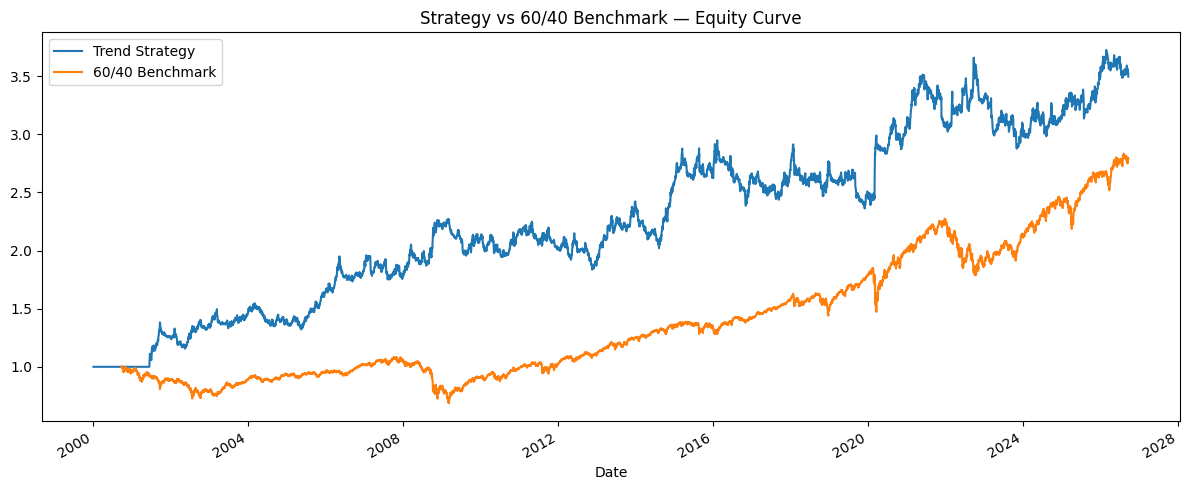

In [41]:
fig, ax = plt.subplots(figsize=(12, 5))
metrics_full['equity_curve'].plot(ax=ax, label='Trend Strategy')
benchmark_metrics['equity_curve'].plot(ax=ax, label='60/40 Benchmark')
ax.set_title('Strategy vs 60/40 Benchmark — Equity Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [49]:
corr_with_benchmark = net_portfolio_return.corr(benchmark_returns)
print(f'Correlation with 60/40 benchmark: {corr_with_benchmark:.3f}')

# Strategy return during benchmark's worst drawdown periods
# The bad_benchmark_days and aligned dataframe are already correctly defined and aligned in the previous cell (w7tQRdQDAAZe)
# Therefore, we can directly use them here.
# benchmark_dd = benchmark_metrics['drawdown_series'] # This is not aligned with net_portfolio_return
# bad_benchmark_days = benchmark_dd < -0.05  # benchmark down >5% from peak
print(f"Strategy avg daily return when benchmark is >5% in drawdown: "
      f"{aligned.loc[bad_benchmark_days, 'strategy'].mean():.5f}")
print(f"Strategy avg daily return overall: {net_portfolio_return.mean():.5f}")

Correlation with 60/40 benchmark: -0.109
Strategy avg daily return when benchmark is >5% in drawdown: 0.00024
Strategy avg daily return overall: 0.00018
